## Câu 2:

### a) Các bước xây dựng mô hình hồi quy:

1. Tìm hiểu vấn đề và mục tiêu
- Xác định bài toán cần giải quyết: Đây là bài toán hồi quy hay bài toán khác ?
- Hiểu rõ ý nghĩa của dữ liệu và mục tiêu
2. Thu thập và khám phá dữ liệu
- Thu thập dữ liệu có liên quan đến vấn đề muốn phân tích. Dữ liệu đa dạng tối thiểu 2000 quan sát.
- Khám phá dữ liệu (EDA): Vẽ biểu đồ trực quan, phát hiện outlier và các giá trị thiếu
3. Xử lý dữ liệu
- Làm sạch dữ liệu: Loại bỏ hoặc xử lý các giá trị thiếu (missing value), loại bỏ outlier nếu cần.
- Mã hóa dữ liệu: Chuyển đổi các biến phân loại thành dạng số (one-hot-encoding, label encoding).
- Chuẩn hóa dữ liệu: chuẩn hóa hoặc scale các biến đầu vào nếu cần (StandardScaler hoặc MinMaxScaler).
- Chia dữ liệu thành tập huấn luyện (training set) và tập kiểm tra (test set) theo tỷ lệ hợp lý (ví dụ: 70%-30% hoặc 80%-20%)
4. Lựa chọn và xây dựng mô hình
- Lựa chọn các loại hồi quy phù hợp:
- Hồi quy tuyến tính (Linear Regression).
- Hồi quy đa thức (Polynomial Regression).
- Hồi quy Ridge, Lasso, hoặc ElasticNet (nếu dữ liệu có vấn đề đa cộng tuyến).
- Các mô hình phi tuyến tính như Random Forest, Gradient Boosting (nếu cần hiệu suất cao
hơn).
- Triển khai mô hình bằng các thư viện scilit-learn, statsmodels.
5. Huấn luyện mô hình
- Đưa dữ liệu vào mô hình để huấn luyện
- Sử dụng kỹ thuật Cross-Validation để đảm bảo tính ổn định của mô hình.
6. Đánh giá mô hình
- Sử dụng các thước đo hiệu suất phù hợp:
- MAE (Mean Absolute Error): Đánh giá độ lệch trung bình của dự báo so với giá trị thực tế.
- MSE (Mean Squared Error): Đánh giá mức độ sai số bằng cách bình phương sự khác biệt, nhấn mạnh các lỗi lớn hơn.
- R^2 (Coefficient of Determination): Đo lường tỷ lệ phương sai của dữ liệu được giải thích bởi mô hình.
- VIF (Variace Inflation Factor): Kiểm tra vấn đề đa cộng tuyến giữa các biến độc lập.
- ...


### b) File dữ liệu thực nghiệm:

1. File dữ liệu: Car details 
2. Dữ liệu bao gồm các thông tin sau
- name: Tên xe
- year: Năm sản xuất
- selling_price: Giá bán xe
- km_driven: Quãng đường đã đi (km)
- fuel: Loại nhiên liệu
- seller_type: Loại người bán
- transmission: Hộp số
- owner: Số lượng chủ sở hữu trước
- mileage: Mức tiêu hao nhiên liệu
- engine: Dung tích động cơ
- max_power: Công suất tối đa
- torque: Mô-men xoắn
- seats: Số ghế
3. File gồm 13 cột và 8128 quan sát

In [1]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import make_scorer, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.feature_selection import SelectFromModel
from tabulate import tabulate

In [2]:
# Đọc file dữ liệu
data = pd.read_csv('D:/Dowload/Cau 2.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


### c) Thực hiện phân tích và tiền xử lý dữ liệu 

In [3]:
# Kiểm tra dữ liệu bị thiếu 
data.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [4]:
# Xóa các dữ liệu bị thiếu
data_cleaned = data.dropna()
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7906 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           7906 non-null   object 
 1   year           7906 non-null   int64  
 2   selling_price  7906 non-null   int64  
 3   km_driven      7906 non-null   int64  
 4   fuel           7906 non-null   object 
 5   seller_type    7906 non-null   object 
 6   transmission   7906 non-null   object 
 7   owner          7906 non-null   object 
 8   mileage        7906 non-null   object 
 9   engine         7906 non-null   object 
 10  max_power      7906 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7906 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 864.7+ KB


In [5]:
# Chuyển đổi dữ liệu: Trích xuất Hãng xe và dùng One-Hot Encoding
df = data_cleaned.copy()

# 1. Trích xuất Hãng xe (Brand) từ chữ đầu tiên của cột 'name'
df['brand'] = df['name'].apply(lambda x: x.split(' ')[0])

# Bỏ cột 'name' gốc đi vì có quá nhiều giá trị duy nhất, dễ gây nhiễu
df = df.drop(columns=['name'])

# 2. Lấy danh sách các cột phân loại (Categorical)
categorical_cols = df.select_dtypes(include=['object']).columns

# 3. Áp dụng One-Hot Encoding 
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7906 entries, 0 to 8127
Columns: 1315 entries, year to brand_Volvo
dtypes: bool(1311), float64(1), int64(3)
memory usage: 10.2 MB


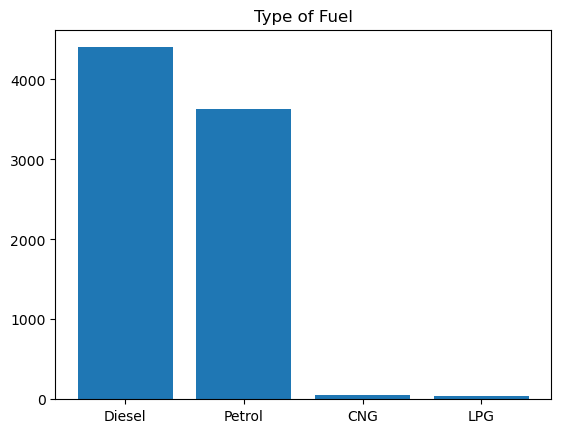

In [6]:
# Phân phối các loại dầu
x=data["fuel"].value_counts()
plt.title("Type of Fuel")
plt.bar(x.index,x.values)
plt.show()

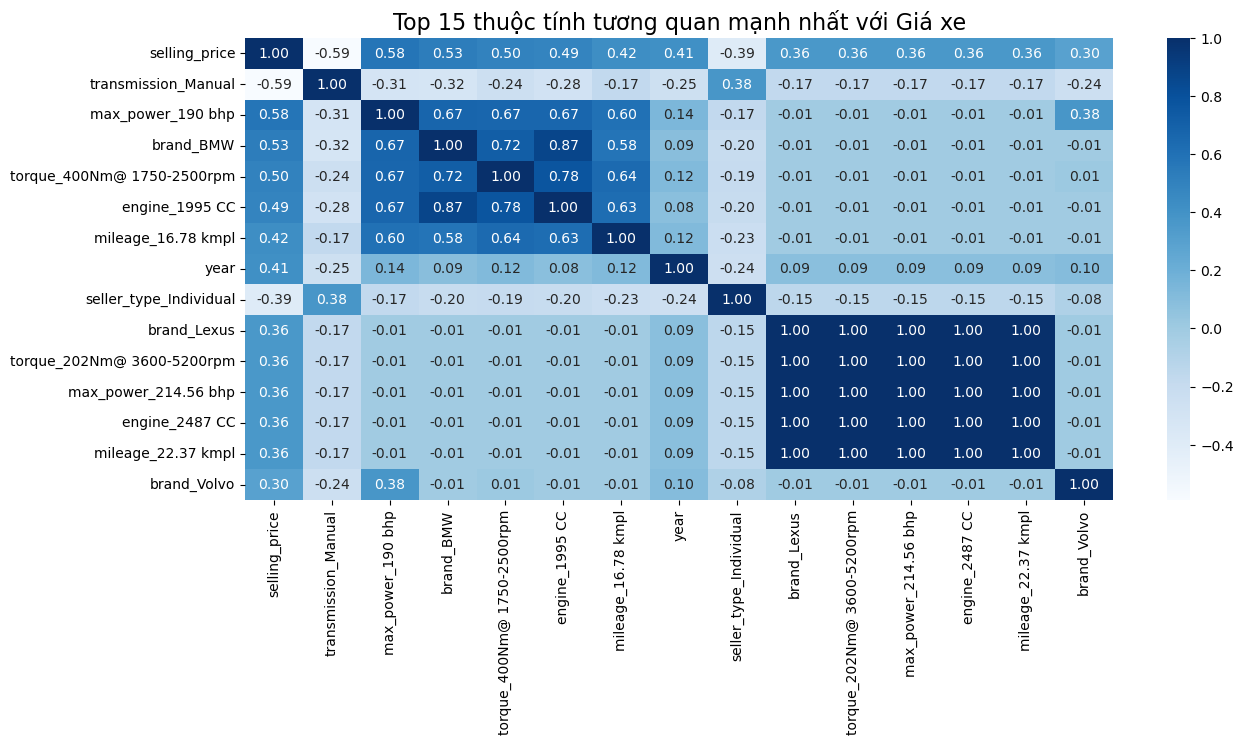

In [16]:
# Mối tương quan giữa các thuộc tính (Lọc ra Top 15 thuộc tính tương quan mạnh nhất với Giá xe)
plt.figure(figsize=(14, 6))

# Đổi dữ liệu về số
df_numeric = df.astype(float) 

# Tính ma trận tương quan
corr = df_numeric.corr()

# Lấy ra 15 biến có tương quan mạnh nhất với cột mục tiêu 'selling_price'
top_corr_features = corr['selling_price'].abs().sort_values(ascending=False).head(15).index

# Vẽ heatmap cho 15 biến này
g = sns.heatmap(df_numeric[top_corr_features].corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title("Top 15 thuộc tính tương quan mạnh nhất với Giá xe", fontsize=16)
plt.show()

In [8]:
# Tạo biến đầu vào (X) và đầu ra (y)
if 'selling_price' in df.columns:
    X = df.drop(columns=['selling_price'])  
    y = df['selling_price']
else:
    print("Cảnh báo: Không tìm thấy cột 'selling_price'. Vui lòng chạy lại từ Cell 10.")

# Chia dữ liệu thành tập huấn luyện (80%) và kiểm tra (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# In kích thước dữ liệu để kiểm tra
print(f"Kích thước X_train: {X_train.shape}")
print(f"Kích thước X_test: {X_test.shape}")


Kích thước X_train: (6324, 1314)
Kích thước X_test: (1582, 1314)


### d) Giới thiệu 3 mô hình hồi quy

#### 1. Mô hình hồi quy Cây quyết định (Decision Tree Regressor): 
- là phương pháp học máy phi tuyến tính được sử dụng để dự đoán giá trị liên tục.
- Cấu trúc: Mô hình này được tổ chức dưới dạng một cây, trong đó mỗi nút đại diện cho một thuộc tính (biến) và mỗi nhánh đại diện cho một giá trị có thể của thuộc tính đó. Các nút lá (leaf nodes) chứa giá trị dự đoán cuối cùng.
- Tại mỗi nút, dữ liệu được chia thành hai hoặc nhiều nhóm dựa trên giá trị của một biến nhất định. Việc chia tách này được thực hiện sao cho giảm thiểu độ lệch chuẩn (variance) trong dữ liệu con.
- Quá trình đào tạo cây quyết định bao gồm việc chia tách dữ liệu liên tục cho đến khi đạt được một tiêu chí dừng, chẳng hạn như số lượng nút lá tối thiểu hoặc độ sâu tối đa của cây.
- Ưu điểm: Dễ hiều và trực quan, không yêu cầu biến đổi dữ liệu phức tạp. Hiệu quả với cả dữ liệu tuyến tính và phi tuyến tính.
- Nhược điểm: Độ nhạy cảm cao với những thay đổi nhỏ trong dữ liệu.

In [9]:
# Xây dựng mô hình Decision Tree
decision_tree_model = DecisionTreeRegressor(random_state=42)

# Dùng tập huấn luyện (X_train, y_train) cho Cross-Validation
scores = cross_val_score(decision_tree_model, X_train, y_train, cv=5)   
   
# In kết quả (Sửa Accuracy thành R-squared)
print("Cross-Validation Scores (R-squared):", scores) 
print("Mean R-squared:", scores.mean()) 
print("Standard Deviation:", scores.std())   

Cross-Validation Scores (R-squared): [0.89309876 0.90886095 0.94922918 0.82229856 0.92930404]
Mean R-squared: 0.9005582980654815
Standard Deviation: 0.04346110506486829


#### 2. Mô hình hồi quy Rừng ngẫu nhiên (Random Forest Regressor):
- là một phương pháp học máy mạnh mẽ, được sử dụng để dự đoán giá trị liên tục dựa trên một tập hợp các biến đầu vào.
- Là một mô hình học tập tổ hợp (ensemble learning), sử dụng nhiều mô hình yếu (weak learners), trong trường hợp này là các cây quyết định để tạo ra một mô hình mạnh mẽ hơn.
- Mỗi cây quyết định trong rừng ngẫu nhiên được huấn luyện trên một tập con ngẫu nhiên của dữ liệu huấn luyện, được lấy mẫu với thay thế.
- Đối với hồi quy, dự đoán cuối cùng của rừng ngẫu nhiên được tính bằng cách lấy trung bình dự đoán của tất cả các cây trong rừng.
- Ưu điểm: Đạt hiệu suất dự đoán cao trên nhiều loại dữ liệu và bài toán khác nhau và tự động đánh giá tầm quan trọng của từng biến, giúp hiểu rõ hơn về dữ liệu.
- Nhược điểm: Huấn luyện và sử dụng mô hình rừng ngẫu nhiên có thể yêu cầu nhiều tài nguyên tính toán hơn so với các mô hình đơn giản khác. Dự đoán của rừng ngẫu nhiên khó giải thích hơn so với các mô hình tuyến tính hoặc cây quyết định đơn lẻ.


In [10]:
# Xây dựng mô hình Random Forest
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(random_forest_model, X_train, y_train, cv=5)   
   
# In kết quả
print("Cross-Validation Scores (R-squared):", scores) 
print("Mean R-squared:", scores.mean()) 
print("Standard Deviation:", scores.std())  

Cross-Validation Scores (R-squared): [0.92709107 0.92245027 0.97092478 0.86835188 0.96333876]
Mean R-squared: 0.9304313522966987
Standard Deviation: 0.03647281425680312


#### 3. Mô hình hồi quy Gradient Boosting:
- là một kỹ thuật học máy mạnh mẽ được sử dụng để cải thiện độ chính xác của dự đoán bằng cách kết hợp nhiều weak learners, thường là các cây quyết định để tạo thành một mô hình mạnh hơn.
- Gradient Boosting sử dụng nhiều mô hình cây quyết định để tạo ra một mô hình hồi quy mạnh hơn. Tuy nhiên, thay vì chỉ đơn giản kết hợp các mô hình, Gradient Boosting xây dựng các mô hình liên tiếp nhau, với mỗi mô hình mới được tạo ra để sửa lỗi của mô hình trước đó.
- Trong quá trình huấn luyện, mỗi mẫu dữ liệu được gán một trọng số và các mẫu khó dự đoán chính xác (các mẫu gây ra sai số cao) được tăng trọng số để mô hình sau tập trung vào chúng hơn.
- Kết quả cuối cùng được tính bằng cách tổng hợp (có trọng số) các dự đoán từ tất cả các mô hình Decision Tree trong dãy.
- Ưu điểm: Tự động điều chỉnh để tập trung vào các mẫu khó dự đoán và thường đạt hiệu suất dự đoán rất tốt trên nhiều loại dữ liệu khác nhau.
- Nhược điểm: Tốn nhiều thời gian và tài nguyên. Cần cẩn thận để tránh quá khớp, đặc biệt khi số lượng cây quyết định rất lớn.

In [11]:
# Xây dựng mô hình Gradient Boosting
gradient_boosting_model = GradientBoostingRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(gradient_boosting_model, X_train, y_train, cv=5)   
   
# In kết quả
print("Cross-Validation Scores (R-squared):", scores) 
print("Mean R-squared:", scores.mean()) 
print("Standard Deviation:", scores.std())

Cross-Validation Scores (R-squared): [0.90535511 0.88749037 0.93834672 0.8626189  0.93249484]
Mean R-squared: 0.9052611876717501
Standard Deviation: 0.028179778116369483


#### Đánh giá mô hình
- Decision Tree: có độ chính xác khá tốt (90%), tuy nhiên độ lệch chuẩn cao (0.04) cho thấy sự không ổn định giữa những lần kiểm cho chéo. Mặc dù dễ triển khai nhưng mô hình này không ổn định và có thể bị ảnh hưởng bởi sự thay đổi trong dữ liệu.
- Random Forest: có độ chính xác cao nhất (93%) và các điểm Cross-Validation đều cao và gần nhau cho thấy mô hình này có hiệu suất ổn định và chính xác hơn trên tập dữ liệu huấn luyện.
- Gradient Boosting: có độ chính xác cao và độ lệch chuẩn mức thấp nhất (0.028) cho thấy mức ổn định cũng khá cao. Điều này cho thấy Gradient Boosting cũng là một mô hình mạnh mẽ,  là lựa chọn thay thế phù hợp cho mô hình Random Forest.


### e) Sử dụng phương pháp lựa chọn thuộc tính để giảm chiều dữ liệu

Sử dụng 'SelectFromModel' để lựa chọn các thuộc tính quan trọng. Những thuộc tính có tầm quan trọng lớn hơn hoặc bằng giá trị trung bình (median) sẽ được giữ lại.

In [15]:
# Sử dụng Random Forest để chọn các thuộc tính quan trọng
feature_selector = RandomForestRegressor(random_state=42)
feature_selector.fit(X_train, y_train)

# Lấy tầm quan trọng của thuộc tính
importances = feature_selector.feature_importances_
# Tạo DataFrame chứa tầm quan trọng và tên thuộc tính
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# In ra các thuộc tính quan trọng
print("Tầm quan trọng của các thuộc tính:")
print(feature_importances)

# Lựa chọn các thuộc tính quan trọng dựa trên ngưỡng
selector = SelectFromModel(feature_selector, threshold="median", prefit=True)
X_train_reduced = selector.transform(X_train)
X_test_reduced = selector.transform(X_test)
selected_features = X_train.columns[selector.get_support()]





Tầm quan trọng của các thuộc tính:
                         Feature  Importance
8            transmission_Manual    0.286842
663            max_power_190 bhp    0.201843
0                           year    0.057905
1                      km_driven    0.053067
3                    fuel_Diesel    0.035908
...                          ...         ...
1186      torque_4.8kgm@ 3000rpm    0.000000
903   torque_11@ 3,000(kgm@ rpm)    0.000000
616            max_power_155 bhp    0.000000
902        torque_119Nm@ 4250rpm    0.000000
994        torque_174Nm@ 4300rpm    0.000000

[1314 rows x 2 columns]


D:\Python\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
D:\Python\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


#### Chạy lại 3 mô hình hồi quy cho dữ liệu đã được giảm chiều

In [13]:
# Khởi tạo các mô hình
models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
}

# Vòng lặp tính toán cho từng mô hình
for model_name, model in models.items():
    # Tính Cross-Validation Scores
    scores = cross_val_score(model, X_train_reduced, y_train, cv=5)
    
    # In kết quả 
    print(f"Model: {model_name}")
    print(f"Mean R-squared: {scores.mean():.4f}")
    print(f"Cross-Validation Scores: {scores}")
    print(f"Standard Deviation: {scores.std():.4f}")
    print("-" * 50)

Model: Decision Tree
Mean R-squared: 0.9020
Cross-Validation Scores: [0.86134671 0.92325565 0.95276893 0.83643088 0.93632746]
Standard Deviation: 0.0451
--------------------------------------------------
Model: Random Forest
Mean R-squared: 0.9308
Cross-Validation Scores: [0.92569361 0.92161744 0.97156487 0.87093296 0.96394573]
Standard Deviation: 0.0359
--------------------------------------------------
Model: Gradient Boosting
Mean R-squared: 0.9039
Cross-Validation Scores: [0.90367783 0.88151888 0.9382295  0.8628756  0.93337846]
Standard Deviation: 0.0291
--------------------------------------------------


### f) Bảng tổng hợp kết quả thực nghiệm và đề xuất phát triển

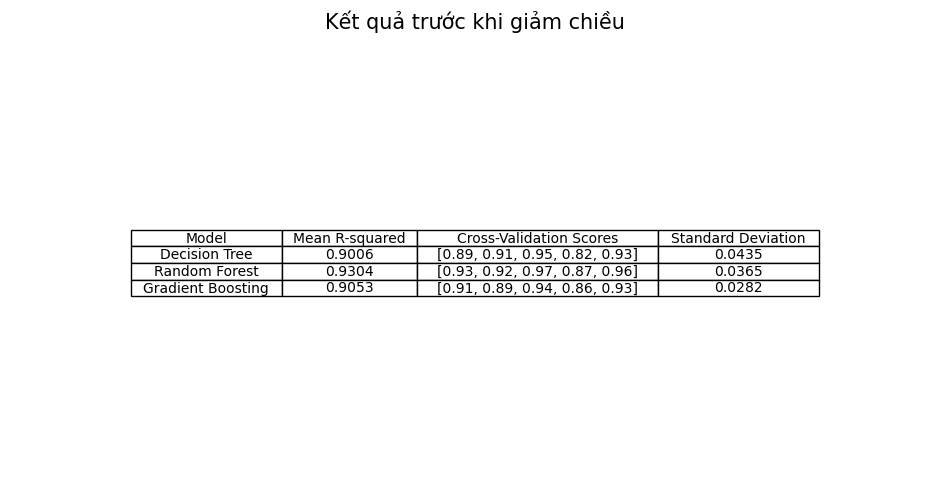

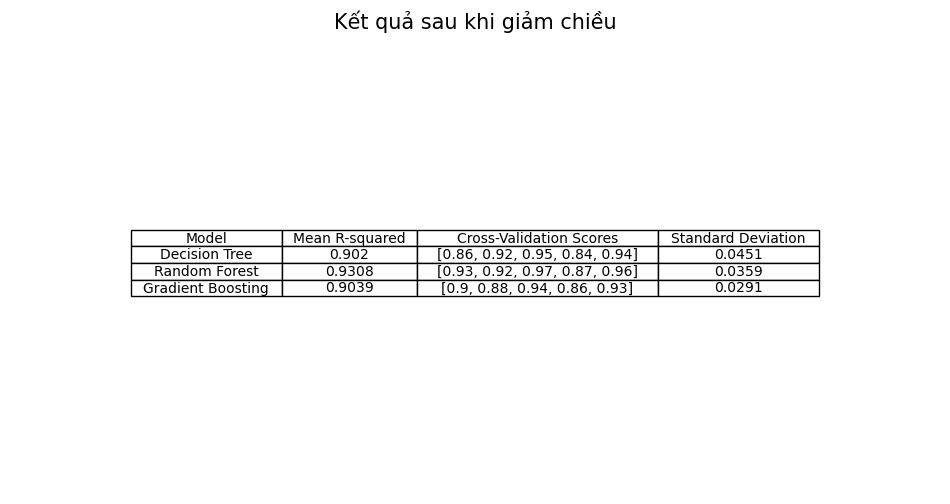

In [14]:
# Hàm thu thập kết quả
def evaluate_models(models, X, y):
    results = []
    for model_name, model in models.items():
        scores = cross_val_score(model, X, y, cv=5)
        mean_score = scores.mean()
        std_dev = scores.std()
        
        # Lấy 2 chữ số sau dấu phẩy
        formatted_scores = [round(score, 2) for score in scores]
        
        results.append({
            "Model": model_name,
            "Mean R-squared": round(mean_score, 4),
            "Cross-Validation Scores": formatted_scores,
            "Standard Deviation": round(std_dev, 4),
        })
    return pd.DataFrame(results)

# Bảng trước khi giảm chiều (Chỉ dùng tập train)
results_before = evaluate_models(models, X_train, y_train)

# Bảng sau khi giảm chiều
results_after = evaluate_models(models, X_train_reduced, y_train)

# Phần hàm plot_table
def plot_table(dataframe, title):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(
        cellText=dataframe.values,
        colLabels=dataframe.columns,
        cellLoc='center',
        loc='center',
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.auto_set_column_width(col=list(range(len(dataframe.columns))))
    plt.title(title, fontsize=15, pad=0)
    plt.show()

# Hiển thị bảng trước khi giảm chiều
plot_table(results_before, "Kết quả trước khi giảm chiều")

# Hiển thị bảng sau khi giảm chiều
plot_table(results_after, "Kết quả sau khi giảm chiều")

#### Đề xuất phát triển:

- Chọn mô hình hồi quy Random Forest làm mô hình chính, sử dụng Grid Search hoặc Random Search để tìm ra bộ siêu tham số tối ưu cho mô hình Random Forest, nhằm cải thiện hiệu suất dự đoán.
- Kết hợp các dự đoán của Random Forest và Gradient Boosting bằng kỹ thuật Ensemble
Learning (ví dụ: Stacking) để cải thiện độ chính xác và độ ổn định của dự đoán cuối cùng.
- Sử dụng các thuật toán mạnh hơn để chọn các thuộc tính quan trọng như Recursive Feature Elimination (RFE) hoặc PCA.
- Tích hợp dữ liệu về giá trị khấu hao trung bình theo thời gian và loại xe để cải thiện khả năng dự đoán, gợi ý giá bán tối ưu cho người bán.
- Tập trung vào phân khúc xe phổ thông, đẩy mạnh các xe tiết kiệm nhiên liệu (mileage).
- Giảm giá trực tiếp cho các xe cũ thuộc phân khúc phổ thông.
- Chính sách đổi xe cũ lấy xe mới (trade-in) với ưu đãi giá tốt.
- Liên kết với ngân hàng để cung cấp gói vay mua xe với lãi suất thấp. Hỗ trợ trả góp cho khách hàng cá nhân.
 